# LOGO-CV Yield Prediction — All States

Extends `experiment_masks.ipynb` (Punjab + MP) to **all 30 states**.

This is the experiment that answers the actual question. Everything in
`02_mask_analysis/` measured *correlation* between GCVI and yield; this measures
**predictive skill** on held-out years, which is what "affects yield prediction" means.

| | |
|---|---|
| **Design** | Leave-One-Group-Out CV by year — train on 11 years, predict the 12th |
| **Conditions** | `none` (ERA5 only) · `raw` · `esri` · `crop` (Jordi rice mask) |
| **Models** | RidgeCV, RandomForest, GradientBoosting |
| **Features** | ERA5 Jul–Oct (tp, pev, t2m, skt, swvl1, lai) + district mean peak GCVI |
| **Metric** | R², de-meaned R², and rank r on the held-out year, averaged over folds |
| **Reported as** | **median across states** — the R² distribution has a long left tail |
| **Excluded** | crop year 2022–23 (`year == 2022`) |

The mask condition is the **only** thing that varies between runs — same districts,
same years, same ERA5 features, same models, same folds. So differences in R² are
attributable to the mask.

> **Why this supersedes Δr.** Pooled correlation is dominated by *between-district*
> variation; a mask can raise it by making districts more comparable without improving
> any forecast. We measured that directly: pooled Δr = +0.44 but per-district Δr =
> +0.008 (p = 0.34), and the two are uncorrelated across states (r = −0.01).


In [1]:
import os, re, glob, json, warnings
import numpy as np, pandas as pd
import nbformat
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats as sps
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'legend.title_fontsize': 13, 'figure.titlesize': 20,
})

ROOT = '../..'
OUT  = f'{ROOT}/outputs'
os.makedirs(OUT, exist_ok=True)

FEATURE_MONTHS = [7, 8, 9, 10]          # matches experiment_masks.ipynb
ERA5_VARS      = ['tp_mm', 'pev_mm', 't2m_c', 'skt', 'swvl1', 'lai_lv']
MIN_ROWS       = 40                      # skip a state if the panel is smaller
MIN_TEST       = 3                       # districts needed in a fold to score a pattern
EXCLUDE_YEARS  = [2022]                  # crop year 2022-23: noisy, see experiment_masks.ipynb
DROP_ZERO_GCVI = False                   # keep gcvi_mean=0 rows; see the note in 1.

# canonical config (REGIONS, REGION_MASKS, NAME_FIXES, load_yield)
_nb  = nbformat.read(f'{ROOT}/notebooks/02_mask_analysis/gsv_preds_exploration.ipynb',
                     as_version=4)
_src = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
_src = _src.replace("os.makedirs('outputs', exist_ok=True)", "").replace("'../../data/", f"'{ROOT}/data/")
CFG = {}
exec(_src, CFG)
REGIONS, REGION_MASKS = CFG['REGIONS'], CFG['REGION_MASKS']
REGION_LABELS, load_yield = CFG['REGION_LABELS'], CFG['load_yield']

GCVI = pd.read_csv(f'{ROOT}/data/processed/gcvi_district_cache.csv')
print(f"{len(REGIONS)} states · GCVI cache {GCVI.shape} "
      f"({GCVI.region_key.nunique()} states, masks {sorted(GCVI['mask'].unique())})")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
30 states · GCVI cache (24084, 5) (30 states, masks ['crop', 'esri', 'jordi', 'raw'])


## 1. Panel assembly

In [2]:
_ABBR = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

def load_era5(region_key):
    f = f'{ROOT}/data/processed/era5_kharif_features_{region_key}.csv'
    if not os.path.exists(f):
        return None
    e = pd.read_csv(f)
    e = e[e['month'].isin(FEATURE_MONTHS)].copy()
    e['month_name'] = e['month'].map({m: _ABBR[m-1] for m in FEATURE_MONTHS})
    w = e.pivot_table(index=['district','year'], columns='month_name', values=ERA5_VARS)
    w.columns = [f'{v}_{m}' for v, m in w.columns]
    return w.reset_index()


# ── district-years where a mask retains no pixels ─────────────────────────
# zonal_stats returns no mean for those, and the cache stores gcvi_mean = 0.
# The obvious worry is that zero is not a low GCVI value but "no observation",
# and feeding it as a number fabricates a signal. We TESTED that by dropping
# those rows from a common panel (a district-year removed from all four
# conditions if any mask is empty there, so the comparison stays controlled).
#
# Result: every condition got WORSE, including `none`.
#
#   RF median          none     raw    esri    crop
#   R2        keep    0.157   0.229   0.220   0.221
#             drop    0.133   0.131   0.134   0.133
#   R2_dm     keep    0.294   0.313   0.320   0.395
#             drop    0.294   0.313   0.320   0.340
#
# gcvi_mean = 0 marks "this district grows (almost) no rice", which is real
# information about its yield -- a crude rice-presence indicator carried in the
# GCVI column. Dropping those rows deletes that signal and also removes the
# low-rice districts that were easiest to rank. So the zeros are KEPT.
#
# DROP_ZERO_GCVI = True reproduces the drop run. Note it costs Gujarat 52% of
# its rows, Nagaland 46%, Rajasthan 37%, MP 21%, and wipes out Goa, Andaman and
# Dadra & Nagar Haveli entirely (100% empty Jordi masks).

def zero_gcvi_keys(region_key):
    """(district, year) pairs where any mask used for this state retains no pixels."""
    masks = set(REGION_MASKS[region_key]) - {'raw'}
    g = GCVI[(GCVI.region_key == region_key) & (GCVI['mask'].isin(masks))]
    bad = g[g['gcvi_mean'] == 0]
    return set(zip(bad['district'], bad['year']))


def build_panel(region_key, condition):
    """condition: 'none' | 'raw' | 'esri' | 'crop'  ('crop' resolves to crop/jordi)."""
    era5 = load_era5(region_key)
    if era5 is None:
        return None
    y = load_yield(REGIONS[region_key]['state_name'])[['district','year','yield_kg_ha']]
    if condition == 'none':
        p = era5.merge(y, on=['district','year'], how='inner')
    else:
        m = REGION_MASKS[region_key][2] if condition == 'crop' else condition
        g = GCVI[(GCVI.region_key == region_key) & (GCVI['mask'] == m)][
                ['district','year','gcvi_mean']]
        if g.empty:
            return None
        p = era5.merge(g, on=['district','year'], how='inner') \
                .merge(y, on=['district','year'], how='inner')
    if EXCLUDE_YEARS:
        p = p[~p['year'].isin(EXCLUDE_YEARS)]
    if DROP_ZERO_GCVI:
        bad = zero_gcvi_keys(region_key)
        if bad:
            keep = [(d, y) not in bad for d, y in zip(p['district'], p['year'])]
            p = p[keep]
    return p.dropna()

# how much would the zero-drop cost each state?  (diagnostic only -- this cell
# must leave DROP_ZERO_GCVI exactly as it found it)
_saved = DROP_ZERO_GCVI
_rows = []
for _k in REGIONS:
    DROP_ZERO_GCVI = True
    _keep = build_panel(_k, 'crop')
    DROP_ZERO_GCVI = False
    _full = build_panel(_k, 'crop')
    if _full is None or len(_full) == 0:
        continue
    _n_keep = 0 if _keep is None else len(_keep)
    _rows.append({'state': REGION_LABELS.get(_k, _k), 'rows_before': len(_full),
                  'rows_after': _n_keep,
                  'pct_dropped': 100 * (1 - _n_keep / len(_full))})
DROP_ZERO_GCVI = _saved

_d = pd.DataFrame(_rows).sort_values('pct_dropped', ascending=False)
print(f"rows the zero-drop WOULD remove (crop condition)   "
      f"[DROP_ZERO_GCVI is {DROP_ZERO_GCVI}]\n")
print(_d[_d.pct_dropped > 0].round(1).to_string(index=False))
print(f"\n{(_d.rows_after < MIN_ROWS).sum()} states would fall below MIN_ROWS={MIN_ROWS}")

rows the zero-drop WOULD remove (crop condition)   [DROP_ZERO_GCVI is False]

                    state  rows_before  rows_after  pct_dropped
     Dadra & Nagar Haveli           18           0        100.0
                      Goa           22           0        100.0
Andaman & Nicobar Islands           27           0        100.0
                  Gujarat          226         109         51.8
                 Nagaland          121          66         45.5
              Uttarakhand          143          88         38.5
                Rajasthan          224         141         37.1
         Himachal Pradesh          120          88         26.7
                  Mizoram           88          66         25.0
                  Manipur           85          67         21.2
                Karnataka          318         252         20.8
              Maharashtra          267         212         20.6
           Madhya Pradesh          518         412         20.5
                  Haryana 

## 2. Run LOGO-CV for every state × condition × model

Each fold holds out one year entirely, trains on the remaining years, and scores on
the held-out year. Crop year 2022–23 (`year == 2022`) is dropped throughout — the
sensitivity analysis in `experiment_masks.ipynb` flagged it as noisy, and excluding it
flips Madhya Pradesh from mixed to uniformly positive.

**Three metrics per fold**, because plain R² conflates two different failures:

| metric | what it scores | blind to |
|---|---|---|
| `r2` | absolute kg/ha accuracy | — |
| `r2_dm` | R² after removing the held-out year's mean from predictions *and* actuals | the year's overall level |
| `rank_r` | Spearman r(pred, actual) within the held-out year | level *and* scale |

LOGO-CV by year makes level error structurally unavoidable: the model never sees the
held-out year, so a nationwide good or bad monsoon is not knowable from the training
folds. `r2` punishes that; `r2_dm` and `rank_r` isolate the part a mask could plausibly
help with — telling districts apart within a year.

This matters concretely. Nagaland scores `r2 = -1.92` but `r2_dm = +0.52`,
`rank_r = +0.82`: the district ranking is good and the level is wrong. Reporting `r2`
alone would discard that state as a failure.

In [3]:
CONDITIONS = ['none', 'raw', 'esri', 'crop']

def models():
    return {
        'Ridge': Pipeline([('sc', StandardScaler()),
                           ('m', RidgeCV(alphas=np.logspace(-2, 4, 50)))]),
        'RF':    RandomForestRegressor(n_estimators=100, max_depth=5,
                                       max_features='sqrt', random_state=42),
        'GBR':   GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                           learning_rate=0.1, random_state=42),
    }

def fold_metrics(actual, pred):
    """r2 (level), r2_dm (pattern only), rank_r (ordering only)."""
    r2 = r2_score(actual, pred)
    dm = r2_score(actual - actual.mean(), pred - pred.mean())
    rk = (sps.spearmanr(pred, actual).statistic
          if np.std(pred) > 0 and np.std(actual) > 0 else np.nan)
    return r2, dm, rk


rows, skipped = [], []
for k in REGIONS:
    for cond in CONDITIONS:
        p = build_panel(k, cond)
        if p is None or len(p) < MIN_ROWS or p['year'].nunique() < 3:
            skipped.append((k, cond, 'no panel' if p is None else f'n={0 if p is None else len(p)}'))
            continue
        feats = [c for c in p.columns if c not in ('district','year','yield_kg_ha')]
        X, yv, grp = p[feats], p['yield_kg_ha'], p['year']
        for name in models():
            r2s, dms, rks, rmses = [], [], [], []
            for tr, te in LeaveOneGroupOut().split(X, yv, grp):
                if len(te) < MIN_TEST:            # too few districts to score a pattern
                    continue
                m = models()[name]
                m.fit(X.iloc[tr], yv.iloc[tr])
                pr = m.predict(X.iloc[te])
                ac = yv.iloc[te].values
                r2, dm, rk = fold_metrics(ac, pr)
                r2s.append(r2); dms.append(dm); rmses.append(float(np.sqrt(mean_squared_error(ac, pr))))
                if not np.isnan(rk):
                    rks.append(rk)
            if not r2s:
                continue
            rows.append({'region_key': k, 'label': REGION_LABELS.get(k, k),
                         'condition': cond, 'model': name,
                         'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s),
                         'r2_median': np.median(r2s),
                         'r2_dm': np.mean(dms), 'r2_dm_median': np.median(dms),
                         'rank_r': np.mean(rks) if rks else np.nan,
                         'rmse_mean': np.mean(rmses), 'n_folds': len(r2s),
                         'n_rows': len(p), 'n_districts': p['district'].nunique()})
    print(f"  {k:<20} done", flush=True)

R = pd.DataFrame(rows)
R.to_csv(f'{OUT}/logo_cv_all_states.csv', index=False)
print(f"\n{len(R)} experiments · {R.region_key.nunique()} states "
      f"· years excluded: {EXCLUDE_YEARS}")
if skipped:
    print(f"skipped {len(skipped)}: {skipped[:8]}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

  puducherry           done


  chandigarh           done


  andaman_nicobar      done


  dadra_nagar_haveli   done



300 experiments · 25 states · years excluded: [2022]
skipped 20: [('goa', 'none', 'n=22'), ('goa', 'raw', 'n=22'), ('goa', 'esri', 'n=22'), ('goa', 'crop', 'n=22'), ('puducherry', 'none', 'n=33'), ('puducherry', 'raw', 'n=33'), ('puducherry', 'esri', 'n=33'), ('puducherry', 'crop', 'n=33')]


## 3. Which states are trend-dominated?

Jharkhand raised the pooled GCVI–yield correlation from 0.36 (raw) to 0.51 (Jordi mask),
yet *every* LOGO-CV fold is negative. The reason is that its pooled correlation is not
cross-district signal at all — it is co-trending. Yields run 855 → 3022 → 1850 kg/ha
across the panel, GCVI trends upward too, and a correlation over pooled district-years
picks that up.

Decomposing pooled r into two parts makes it visible:

- **year-mean r** — correlate the state's yearly *mean* GCVI against its yearly *mean*
  yield (n = number of years). This is the co-trending / common-shock component.
- **within-year r** — de-mean both by year, then correlate. This is the cross-district
  component, and it is the only part LOGO-CV can reward, because holding out a whole
  year removes the year means from the test set entirely.

A state where `|year-mean r| >> |within-year r|` has a pooled correlation that carries
no out-of-sample value. Flagging those is not a way to discard inconvenient states — it
is a statement about which metric to read for them.

In [4]:
def decompose(region_key, condition='crop'):
    """Split pooled r(GCVI, yield) into a year-mean and a within-year component."""
    p = build_panel(region_key, condition)
    if p is None or 'gcvi_mean' not in p or p['year'].nunique() < 4:
        return None
    out = {'region_key': region_key, 'condition': condition, 'n_years': p['year'].nunique()}

    out['pooled_r'] = sps.pearsonr(p['gcvi_mean'], p['yield_kg_ha']).statistic

    ym = p.groupby('year')[['gcvi_mean', 'yield_kg_ha']].mean()
    out['year_mean_r'] = (sps.pearsonr(ym['gcvi_mean'], ym['yield_kg_ha']).statistic
                          if len(ym) > 2 else np.nan)

    d = p.copy()
    for col in ['gcvi_mean', 'yield_kg_ha']:
        d[col] = d[col] - d.groupby('year')[col].transform('mean')
    out['within_year_r'] = sps.pearsonr(d['gcvi_mean'], d['yield_kg_ha']).statistic

    # linear trend in the state-mean yield
    lr = sps.linregress(ym.index.astype(float), ym['yield_kg_ha'])
    out['yield_trend'] = lr.slope
    out['yield_trend_p'] = lr.pvalue
    lg = sps.linregress(ym.index.astype(float), ym['gcvi_mean'])
    out['gcvi_trend'] = lg.slope
    out['gcvi_trend_p'] = lg.pvalue
    return out


TREND = pd.DataFrame([r for r in (decompose(k) for k in REGIONS) if r])
TREND['label'] = TREND['region_key'].map(REGION_LABELS).fillna(TREND['region_key'])
TREND['gap'] = TREND['year_mean_r'].abs() - TREND['within_year_r'].abs()

# trend-dominated: yields move significantly over time AND the pooled correlation
# is driven far more by the year means than by cross-district variation.
TREND['trend_dominated'] = (TREND['yield_trend_p'] < 0.05) & (TREND['gap'] > 0.30)
TREND.to_csv(f'{OUT}/logo_cv_trend_diagnostics.csv', index=False)

cols = ['label','pooled_r','year_mean_r','within_year_r','gap',
        'yield_trend','yield_trend_p','trend_dominated']
print(f"{TREND['trend_dominated'].sum()} of {len(TREND)} states are trend-dominated\n")
print(TREND.sort_values('gap', ascending=False)[cols].round(3).to_string(index=False))

TREND_STATES = set(TREND.loc[TREND['trend_dominated'], 'region_key'])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


...

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
6 of 30 states are trend-dominated

                    label  pooled_r  year_mean_r  within_year_r    gap  yield_trend  yield_trend_p  trend_dominated
                   Odisha     0.402        0.811         -0.020  0.791       90.921          0.004             True
            Uttar Pradesh     0.213        0.876          0.144  0.732       53.767          0.003             True
                Jharkhand     0.516        0.788          0.089  0.699      144.001          0.046             True


## 4. Does the crop mask improve prediction?

In [5]:
# ── why median, not mean ──────────────────────────────────────────────────
# R2 on a held-out year is unbounded below: one state whose yields shift level
# between years can score -12 and drag the cross-state mean to nonsense. The
# distribution has a long left tail (Jharkhand -11.98, Tripura -3.10, Nagaland
# -1.92, Tamil Nadu -1.43), so the MEDIAN across states is the honest summary.
# The mean is printed alongside only to show how far it is pulled.

METRICS = ['r2_mean', 'r2_dm', 'rank_r']
MET_LABEL = {'r2_mean': 'R² (level)', 'r2_dm': 'R² de-meaned', 'rank_r': 'rank r'}
ORDER = ['none', 'raw', 'esri', 'crop']


def summarise(df, model='RF', tag=''):
    sub = df[df.model == model]
    n = sub.region_key.nunique()
    print(f"\n{model}{'  ·  ' + tag if tag else ''}   ({n} states, years excluded {EXCLUDE_YEARS})")
    print(f"{'metric':<16}{'stat':<9}" + ''.join(f"{c:>10}" for c in ORDER))
    print('-' * (25 + 10 * len(ORDER)))
    for met in METRICS:
        w = sub.pivot_table(index='region_key', columns='condition', values=met)
        w = w.reindex(columns=[c for c in ORDER if c in w.columns])
        for stat in ['median', 'mean']:
            v = getattr(w, stat)()
            print(f"{MET_LABEL[met] if stat=='median' else '':<16}{stat:<9}"
                  + ''.join(f"{v.get(c, np.nan):>+10.3f}" for c in w.columns))
    return sub


summarise(R, 'RF')
summarise(R[~R.region_key.isin(TREND_STATES)], 'RF', 'trend-dominated states removed')

# ── the key paired comparison: crop mask vs raw GCVI ──────────────────────
piv = R.pivot_table(index=['region_key','label','model'], columns='condition',
                    values='r2_mean').reset_index()
for c in ['raw','esri','crop']:
    if c in piv and 'none' in piv:
        piv[f'gain_{c}_vs_none'] = piv[c] - piv['none']
piv['gain_crop_vs_raw'] = piv['crop'] - piv['raw'] if 'crop' in piv and 'raw' in piv else np.nan
piv.to_csv(f'{OUT}/logo_cv_gains.csv', index=False)

print("\n\nCrop mask vs raw GCVI, paired within state")
print(f"{'model':<8}{'metric':<15}{'median Δ':>10}{'mean Δ':>9}{'% states +':>12}{'n':>5}"
      "   Wilcoxon")
print('-' * 76)
for mdl in ['Ridge','RF','GBR']:
    for met in METRICS:
        w = R[R.model == mdl].pivot_table(index='region_key', columns='condition', values=met)
        if not {'raw','crop'}.issubset(w.columns):
            continue
        d = (w['crop'] - w['raw']).dropna()
        if len(d) < 5:
            continue
        try:
            st, pv = sps.wilcoxon(d)
            wtxt = f"W={st:.0f}, p={pv:.3f}{' *' if pv < 0.05 else ''}"
        except ValueError:
            wtxt = 'n/a'
        print(f"{mdl:<8}{MET_LABEL[met]:<15}{d.median():>+10.3f}{d.mean():>+9.3f}"
              f"{100*(d>0).mean():>11.0f}%{len(d):>5}   {wtxt}")

print("\nWilcoxon signed-rank is used rather than a paired t-test: the per-state\n"
      "differences are heavy-tailed, which is exactly the condition the t-test\n"
      "assumes away.")


RF   (25 states, years excluded [2022])
metric          stat           none       raw      esri      crop
-----------------------------------------------------------------
R² (level)      median       +0.157    +0.229    +0.220    +0.221
                mean         -0.765    -0.720    -0.652    -0.635
R² de-meaned    median       +0.294    +0.313    +0.320    +0.395
                mean         +0.333    +0.350    +0.341    +0.355
rank r          median       +0.583    +0.586    +0.597    +0.660
                mean         +0.565    +0.571    +0.571    +0.586

RF  ·  trend-dominated states removed   (19 states, years excluded [2022])
metric          stat           none       raw      esri      crop
-----------------------------------------------------------------


R² (level)      median       +0.291    +0.350    +0.304    +0.346
                mean         -0.178    -0.138    -0.150    -0.130
R² de-meaned    median       +0.520    +0.547    +0.522    +0.538
                mean         +0.419    +0.433    +0.422    +0.439
rank r          median       +0.741    +0.758    +0.751    +0.766
                mean         +0.667    +0.664    +0.665    +0.685


Crop mask vs raw GCVI, paired within state
model   metric           median Δ   mean Δ  % states +    n   Wilcoxon
----------------------------------------------------------------------------
Ridge   R² (level)         +0.000   +0.049         52%   25   W=144, p=0.634
Ridge   R² de-meaned       +0.007   +0.080         56%   25   W=103, p=0.113
Ridge   rank r             +0.015   +0.013         60%   25   W=97, p=0.080
RF      R² (level)         +0.003   +0.085         52%   25   W=132, p=0.426
RF      R² de-meaned       -0.007   +0.005         40%   25   W=162, p=1.000
RF      rank r             

## 5. Figures

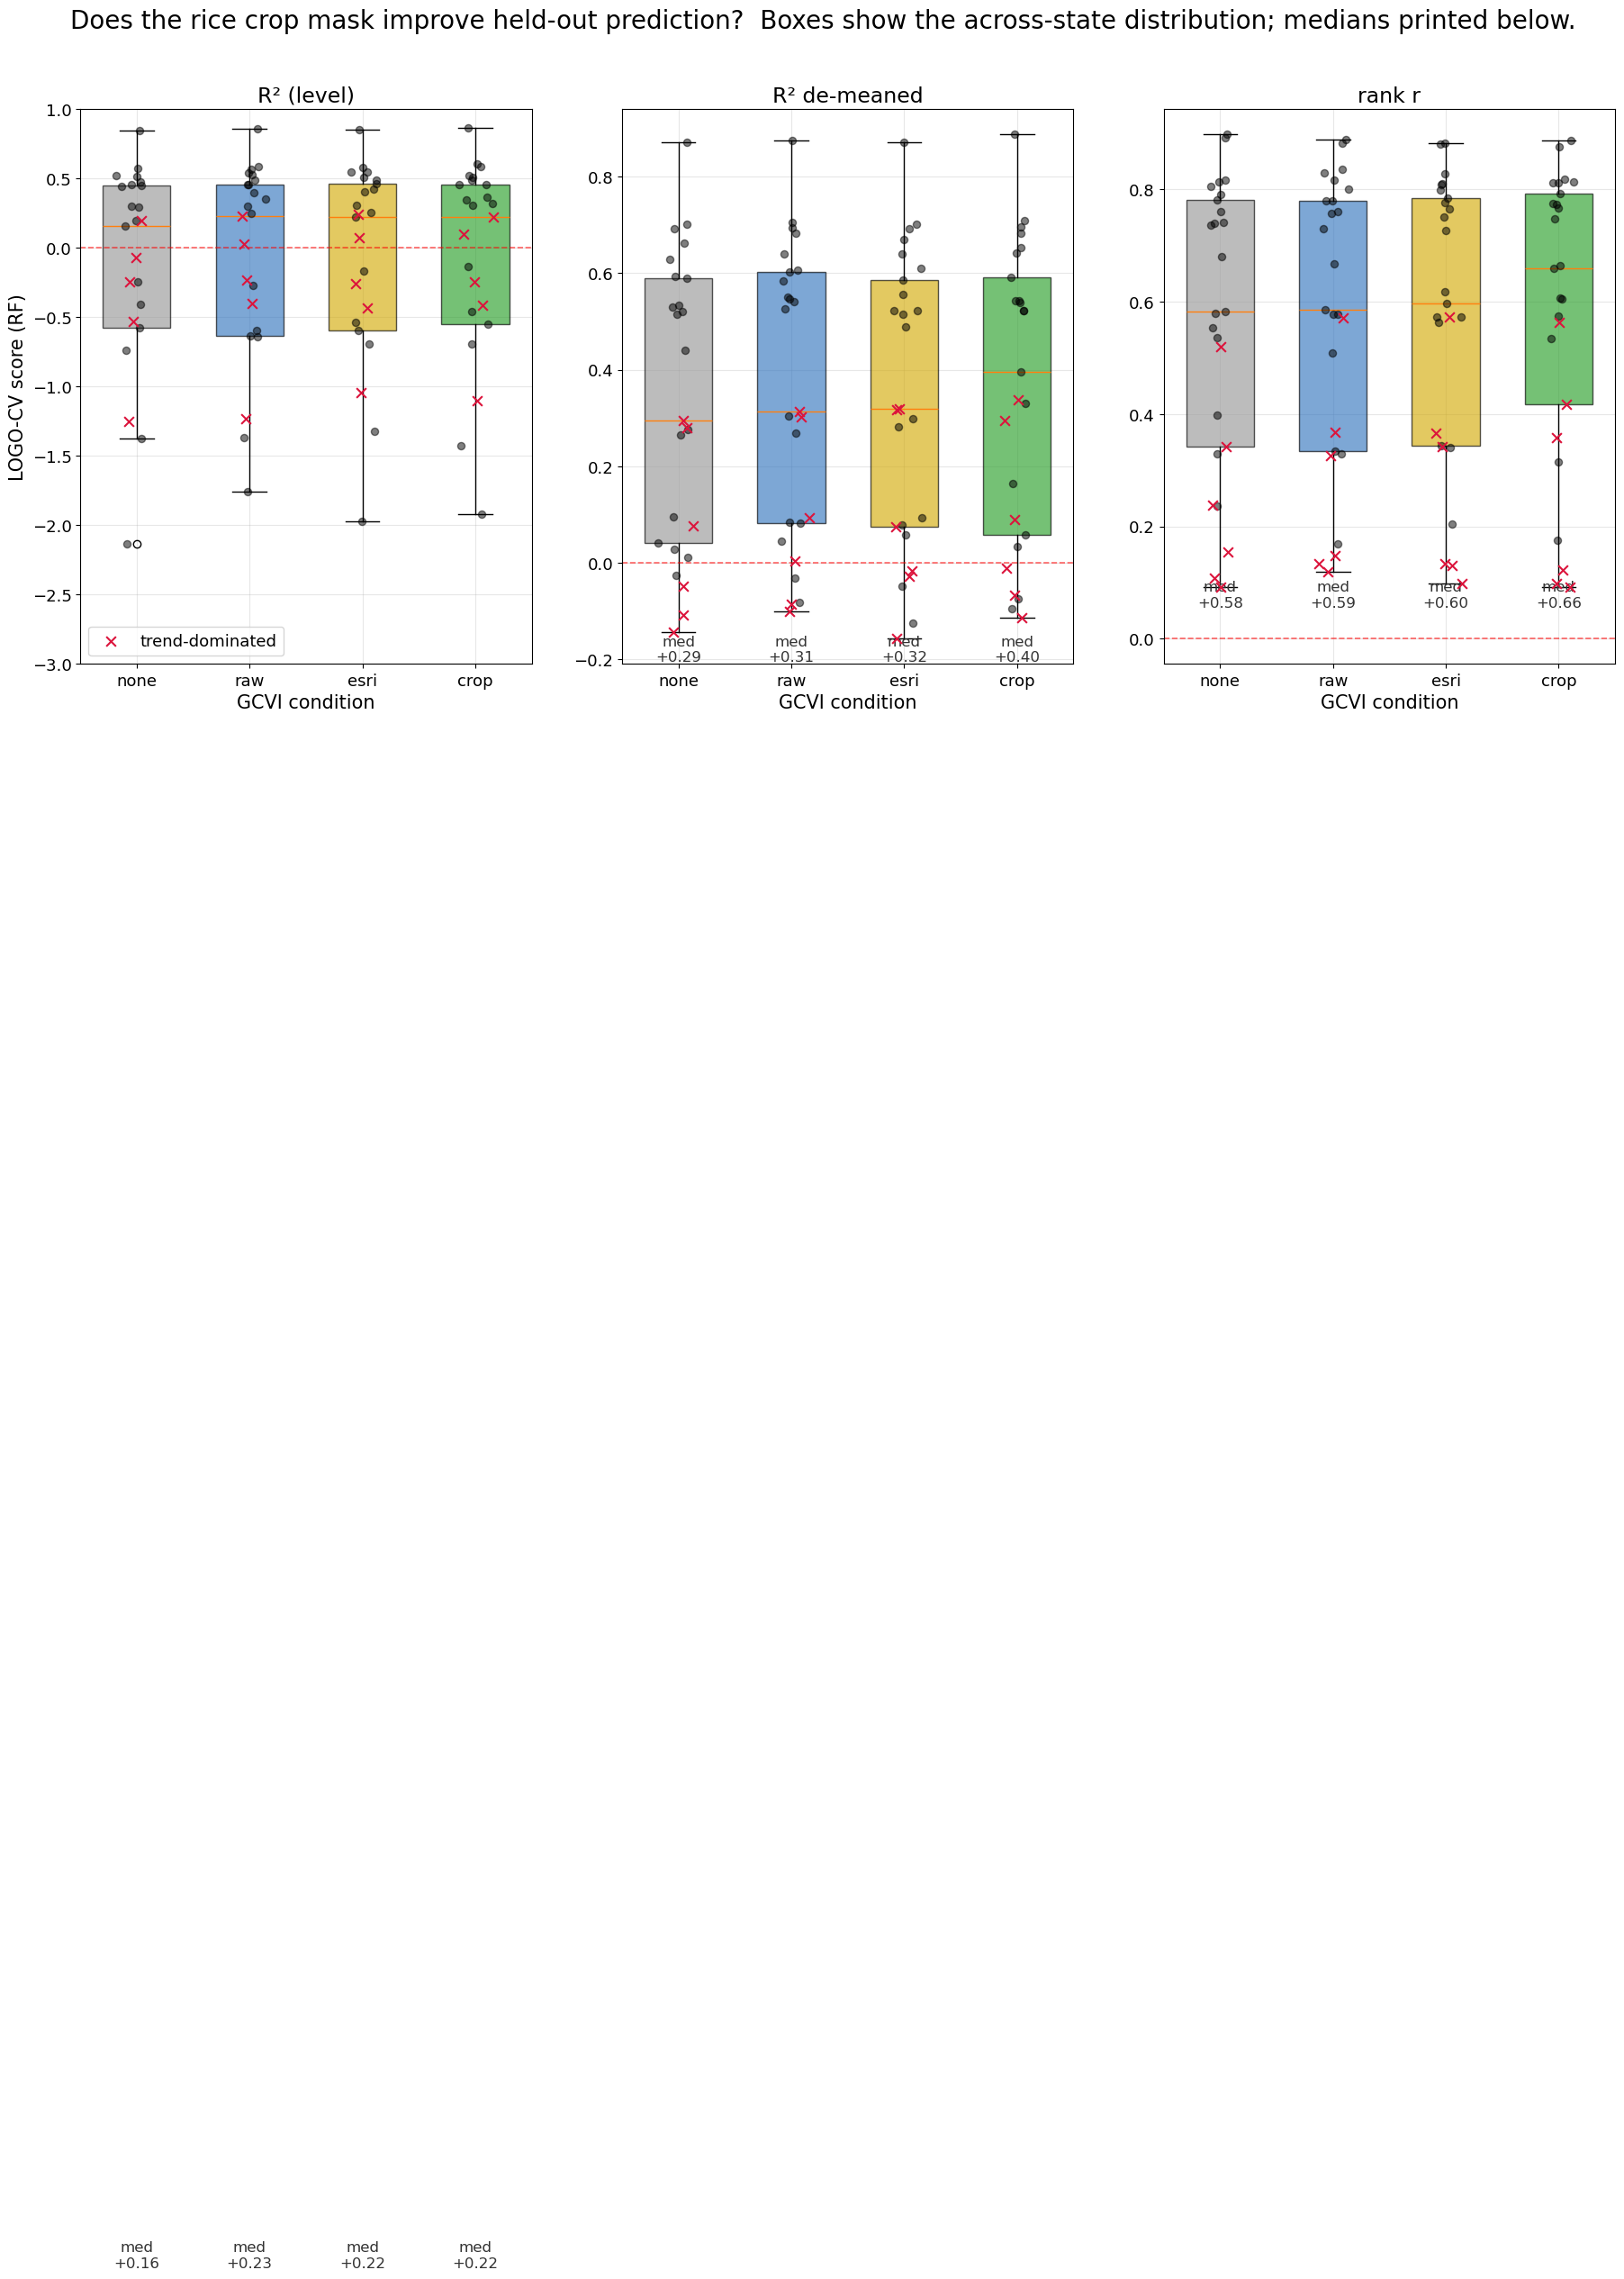

R² (level) panel is clipped at -3; Jharkhand (-11.98) and Tripura (-3.10) sit below the axis.


In [6]:
# RF only — comparing conditions requires holding the model fixed, and picking the
# best model per state per condition lets model selection masquerade as a mask effect.
RF = R[R.model == 'RF']
COL = {'none':'#999999','raw':'#3778bf','esri':'#d4ac0d','crop':'#2ca02c'}

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, met in zip(axes, METRICS):
    w = RF.pivot_table(index='region_key', columns='condition', values=met)
    w = w.reindex(columns=[c for c in ORDER if c in w.columns])
    data = [w[c].dropna() for c in w.columns]
    bp = ax.boxplot(data, labels=list(w.columns), patch_artist=True,
                    showmeans=False, widths=0.6)
    for b, c in zip(bp['boxes'], w.columns):
        b.set_facecolor(COL[c]); b.set_alpha(0.65)
    for i, c in enumerate(w.columns):
        d = w[c].dropna()
        flag = d.index.isin(TREND_STATES)
        ax.scatter(np.random.normal(i+1, 0.06, (~flag).sum()), d[~flag],
                   s=34, color='black', alpha=0.5, zorder=3)
        ax.scatter(np.random.normal(i+1, 0.06, flag.sum()), d[flag],
                   s=60, color='crimson', marker='x', zorder=4,
                   label='trend-dominated' if i == 0 else None)
        ax.text(i+1, ax.get_ylim()[0], f"med\n{d.median():+.2f}", ha='center',
                va='bottom', fontsize=12, color='#333')
    ax.axhline(0, color='red', ls='--', lw=1.2, alpha=0.6)
    ax.set_title(MET_LABEL[met]); ax.set_xlabel('GCVI condition')
    ax.grid(alpha=0.3)
    if met == 'r2_mean':
        ax.set_ylim(-3, 1)      # clip the long left tail so the boxes stay readable
        ax.set_ylabel('LOGO-CV score (RF)')
        ax.legend(loc='lower left')

fig.suptitle('Does the rice crop mask improve held-out prediction?  '
             'Boxes show the across-state distribution; medians printed below.', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/logo_cv_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("R² (level) panel is clipped at -3; Jharkhand (-11.98) and Tripura (-3.10) "
      "sit below the axis.")

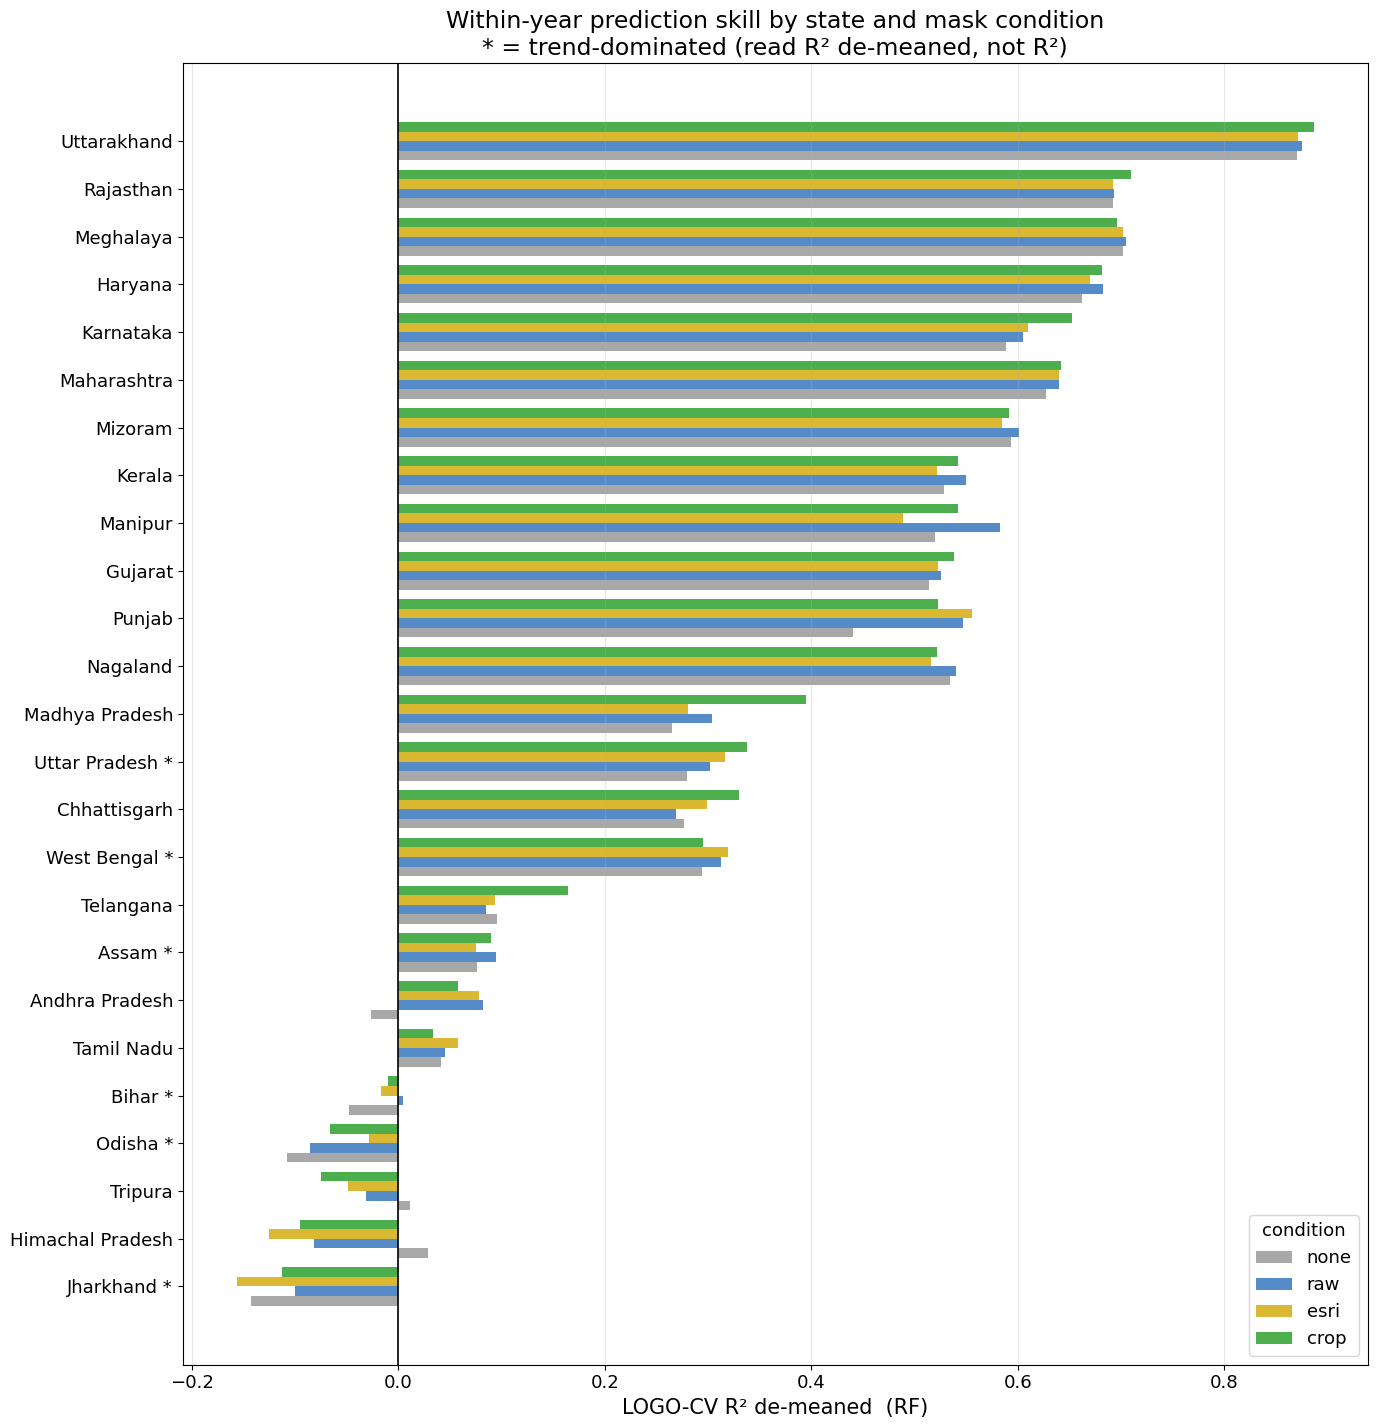

In [7]:
# per-state scores by condition, RF, sorted by the de-meaned score
w = RF.pivot_table(index='region_key', columns='condition', values='r2_dm')
w = w.reindex(columns=[c for c in ORDER if c in w.columns]).sort_values('crop')
labels = [REGION_LABELS.get(k, k) + (' *' if k in TREND_STATES else '') for k in w.index]

fig, ax = plt.subplots(figsize=(14, 0.46*len(w)+3))
ypos = np.arange(len(w))
for i, c in enumerate(w.columns):
    ax.barh(ypos + (i-1.5)*0.2, w[c], height=0.2, label=c, color=COL[c], alpha=0.85)
ax.set_yticks(ypos); ax.set_yticklabels(labels)
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('LOGO-CV R² de-meaned  (RF)')
ax.legend(title='condition', loc='lower right')
ax.set_title('Within-year prediction skill by state and mask condition\n'
             '* = trend-dominated (read R² de-meaned, not R²)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}/logo_cv_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Does prediction gain relate to correlation gain?

The correlation work produced pooled Δr. If Δr were a good proxy for predictive value,
these would correlate.

In [8]:
try:
    sp = pd.read_csv(f'{OUT}/state_predictors.csv')[['region_key','delta','rel']]
    cmp_ = piv.merge(sp, on='region_key', how='left')
    print(f"{'model':<8}{'r(Δr, ΔR²)':>13}{'p':>9}{'n':>5}")
    print('-'*36)
    for mdl in ['Ridge','RF','GBR']:
        v = cmp_[(cmp_.model==mdl)][['delta','gain_crop_vs_raw']].dropna()
        if len(v) < 5: continue
        r,p = sps.pearsonr(v['delta'], v['gain_crop_vs_raw'])
        print(f"{mdl:<8}{r:>13.2f}{p:>9.3f}{len(v):>5}")
except FileNotFoundError:
    print('state_predictors.csv not found — skipping')

model      r(Δr, ΔR²)        p    n
------------------------------------
Ridge           -0.05    0.801   25
RF              -0.21    0.314   25
GBR             -0.19    0.376   25


## Caveats

- **Report the median, not the mean.** Held-out R² is unbounded below. Jharkhand alone
  (−11.98) moves the cross-state mean R² by roughly 0.55; the median moves by 0.04.
  Every headline number in §4 is a median for this reason.
- **Trend-dominated states need the de-meaned metric.** §3 flags states whose pooled
  GCVI–yield correlation comes from co-trending rather than cross-district signal.
  Their R² is dominated by an unknowable year level and says little about the mask.
- **2022 is excluded** (`EXCLUDE_YEARS`). Set it to `[]` to reproduce the earlier run.
- **ERA5 features were regenerated for all states** by `scripts/era5_extract.py`. The
  extractor was validated against the original MP file: max |diff| ≤ 7e-5 across all
  seven variables, identical row count, no duplicates.
- **`gcvi_mean = 0` for districts with no mask pixels** (inherited from the original
  experiment). In states where the mask is aggressive this injects a block of zeros as
  a feature value — worth a sensitivity run that drops those rows instead.
- **Small states have few rows.** `MIN_ROWS = 40`, ≥3 years, and `MIN_TEST = 3`
  districts per fold are required; skipped combinations are listed in §2.
- **The comparison is RF-only in the figures.** Taking the best model per state per
  condition would let model selection show up as a mask effect.